In [1]:
import pandas as pd

df = pd.read_csv("tickets.csv")   # change path if needed
print("Rows:", df.shape)
print(df.columns)


Rows: (47837, 2)
Index(['Document', 'Topic_group'], dtype='object')


In [2]:
df["clean_text"] = (
    df["Document"]
    .astype(str)
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
)

df = df.dropna(subset=["clean_text", "Topic_group"])
df = df[df["clean_text"].str.len() > 30]

print("After filter:", df.shape)
print(df["Topic_group"].value_counts())


After filter: (47590, 3)
Topic_group
Hardware                 13539
HR Support               10853
Access                    7060
Miscellaneous             7039
Storage                   2772
Purchase                  2460
Internal Project          2114
Administrative rights     1753
Name: count, dtype: int64


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    df["clean_text"],
    df["Topic_group"],
    test_size=0.2,
    stratify=df["Topic_group"],
    random_state=42
)

print("Train:", len(X_train))
print("Val:", len(X_val))


Train: 38072
Val: 9518


C:\Users\dss28\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_15 (Embedding)             │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_13 (SimpleRNN)            │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_68 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_28 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_69 (Dense)                     │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.3921 - loss: 1.6248 - val_accuracy: 0.5775 - val_loss: 1.2705
Epoch 2/20
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.5731 - loss: 1.2920 - val_accuracy: 0.4412 - val_loss: 1.5344
Epoch 3/20
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.5458 - loss: 1.3616 - val_accuracy: 0.4044 - val_loss: 1.5437
Epoch 4/20
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.4432 - loss: 1.5295 - val_accuracy: 0.4931 - val_loss: 1.4489
Epoch 5/20
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.5412 - loss: 1.3709 - val_accuracy: 0.5544 - val_loss: 1.3247
Epoch 6/20
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.5747 - loss: 1.2879 - val_accuracy: 0.5672 - val_loss: 1.2964
Epoch 7/20
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.5945 - loss: 1.2312 - val_accuracy: 0.4961 - val_loss: 1.4330
Epoch 8/20
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.4836 - loss: 1.4574 - 

C:\Users\dss28\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\dss28\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\dss28\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

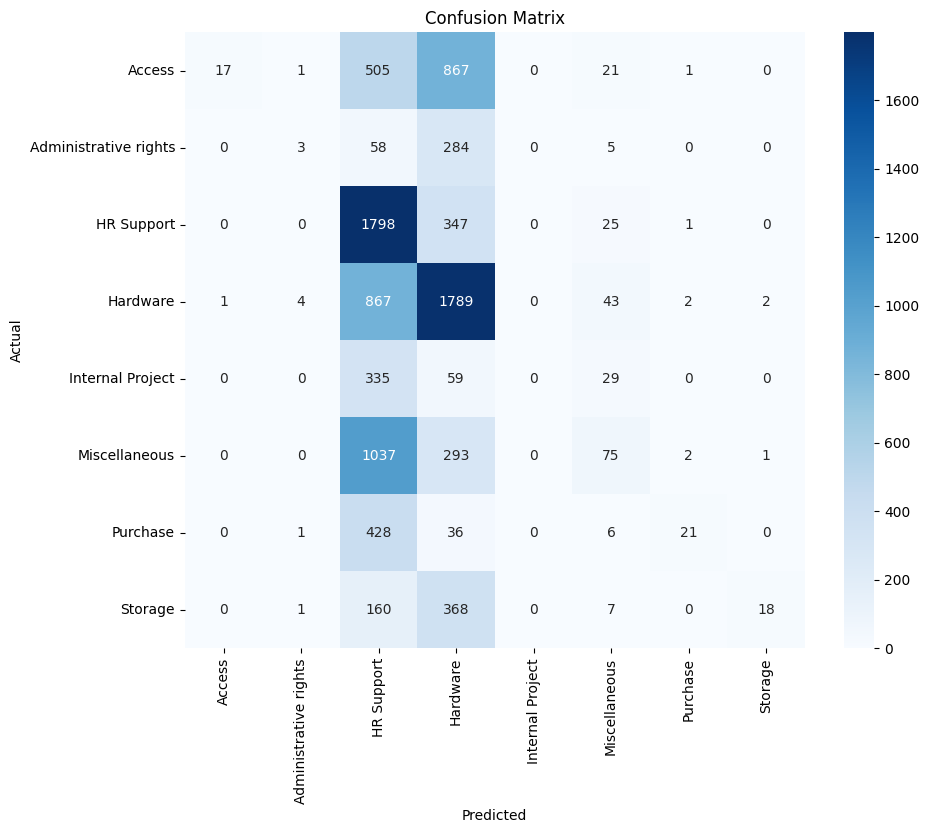

In [38]:
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# -----------------------------
# Parameters
# -----------------------------
vocab_size = 5000      # max number of words
max_len = 50           # max tokens per text
embedding_dim = 50
rnn_units = 64
batch_size = 32
epochs = 20

# -----------------------------
# Tokenize text
# -----------------------------
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=max_len, padding='post')

# -----------------------------
# Encode labels
# -----------------------------
label_encoder = LabelEncoder()
y_train_int = label_encoder.fit_transform(y_train)
y_val_int = label_encoder.transform(y_val)

num_classes = len(label_encoder.classes_)
from tensorflow.keras.utils import to_categorical
y_train_cat = to_categorical(y_train_int, num_classes)
y_val_cat = to_categorical(y_val_int, num_classes)

# -----------------------------
# Compute class weights
# -----------------------------
class_weights_values = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_int),
    y=y_train_int
)
class_weights = dict(enumerate(class_weights_values))

# -----------------------------
# Build RNN model
# -----------------------------
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    SimpleRNN(rnn_units),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

# -----------------------------
# Early stopping
# -----------------------------
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# -----------------------------
# Train model with class weights
# -----------------------------
history = model.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    batch_size=batch_size,
    epochs=epochs,
    # class_weight=class_weights,
    # callbacks=[early_stop]
)

# -----------------------------
# Evaluate
# -----------------------------
val_loss, val_acc = model.evaluate(X_val_pad, y_val_cat)
print(f"Validation Accuracy: {val_acc:.4f}")

# -----------------------------
# Confusion matrix
# -----------------------------
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_labels = np.argmax(model.predict(X_val_pad), axis=1)
y_val_labels = np.argmax(y_val_cat, axis=1)

print(classification_report(y_val_labels, y_pred_labels, target_names=label_encoder.classes_))

cm = confusion_matrix(y_val_labels, y_pred_labels)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


C:\Users\dss28\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_17 (Embedding)             │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_3 (GRU)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_72 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_30 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_73 (Dense)                     │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 24s 17ms/step - accuracy: 0.1736 - loss: 1.9157 - val_accuracy: 0.5662 - val_loss: 1.2000
Epoch 2/20
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.6818 - loss: 0.7655 - val_accuracy: 0.7553 - val_loss: 0.7511
Epoch 3/20
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.8097 - loss: 0.4633 - val_accuracy: 0.8087 - val_loss: 0.5781
Epoch 4/20
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.8460 - loss: 0.3587 - val_accuracy: 0.8050 - val_loss: 0.5909
Epoch 5/20
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.8670 - loss: 0.2989 - val_accuracy: 0.8132 - val_loss: 0.5708
Epoch 6/20
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.8796 - loss: 0.2576 - val_accuracy: 0.8053 - val_loss: 0.5899
Epoch 7/20
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.8910 - loss: 0.2312 - val_accuracy: 0.8174 - val_loss: 0.5948
Epoch 8/20
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.9066 -

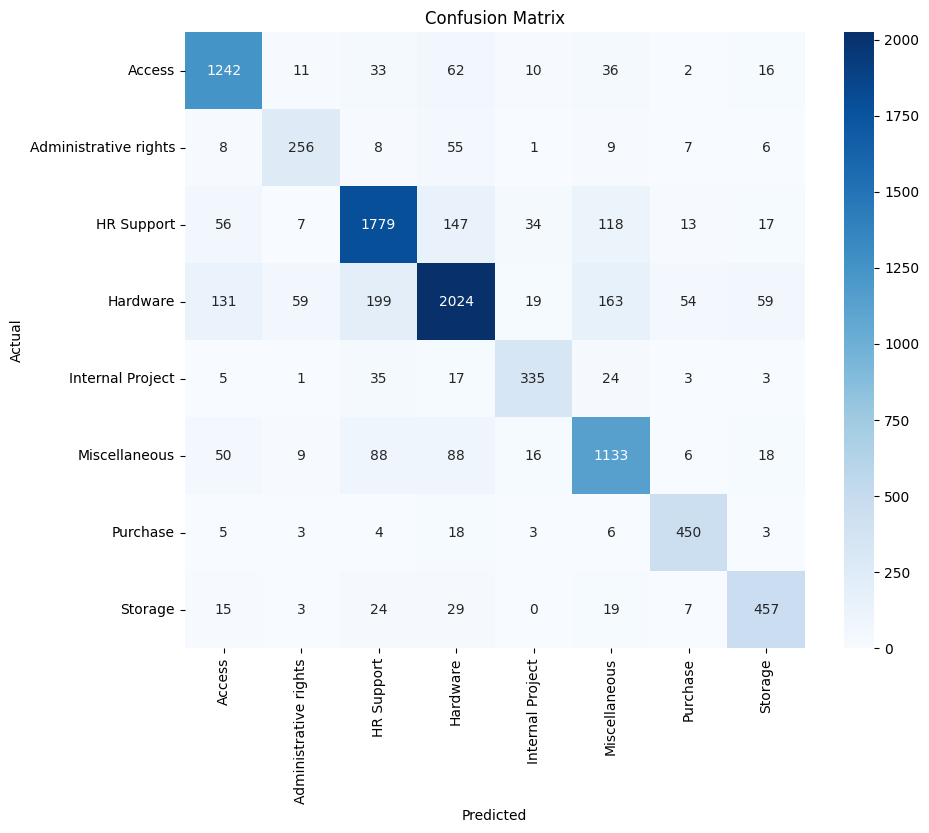

In [42]:
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# -----------------------------
# Parameters
# -----------------------------
vocab_size = 5000      # max number of words
max_len = 50           # max tokens per text
embedding_dim = 50
rnn_units = 64
batch_size = 32
epochs = 20

# -----------------------------
# Tokenize text
# -----------------------------
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=max_len, padding='post')

# -----------------------------
# Encode labels
# -----------------------------
label_encoder = LabelEncoder()
y_train_int = label_encoder.fit_transform(y_train)
y_val_int = label_encoder.transform(y_val)

num_classes = len(label_encoder.classes_)
y_train_cat = to_categorical(y_train_int, num_classes)
y_val_cat = to_categorical(y_val_int, num_classes)

# -----------------------------
# Compute class weights
# -----------------------------
class_weights_values = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_int),
    y=y_train_int
)
class_weights = dict(enumerate(class_weights_values))

# -----------------------------
# Build GRU model
# -----------------------------
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    GRU(rnn_units),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

# -----------------------------
# Early stopping
# -----------------------------
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# -----------------------------
# Train model with class weights
# -----------------------------
history = model.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    batch_size=batch_size,
    epochs=epochs,
    class_weight=class_weights,
    # callbacks=[early_stop]
)

# -----------------------------
# Evaluate
# -----------------------------
val_loss, val_acc = model.evaluate(X_val_pad, y_val_cat)
print(f"Validation Accuracy: {val_acc:.4f}")

# -----------------------------
# Confusion matrix & classification report
# -----------------------------
y_pred_labels = np.argmax(model.predict(X_val_pad), axis=1)
y_val_labels = np.argmax(y_val_cat, axis=1)

print(classification_report(y_val_labels, y_pred_labels, target_names=label_encoder.classes_))

cm = confusion_matrix(y_val_labels, y_pred_labels)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [40]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# -----------------------------
# TF-IDF features
# -----------------------------
vectorizer = TfidfVectorizer(max_features=5000)
X_train_feat = vectorizer.fit_transform(X_train)
X_val_feat = vectorizer.transform(X_val)

# -----------------------------
# Logistic Regression with class weights
# -----------------------------
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_feat, y_train)

# -----------------------------
# Predict & evaluate
# -----------------------------
y_pred = model.predict(X_val_feat)

# Classification report
print(classification_report(y_val, y_pred))

# Confusion matrix
cm = confusion_matrix(y_val, y_pred)
print("Confusion Matrix:\n", cm)

# Accuracy
acc = accuracy_score(y_val, y_pred)
print(f"Validation Accuracy: {acc:.4f}")


                       precision    recall  f1-score   support

               Access       0.89      0.88      0.89      1412
Administrative rights       0.67      0.89      0.76       350
           HR Support       0.89      0.81      0.84      2171
             Hardware       0.86      0.82      0.84      2708
     Internal Project       0.81      0.91      0.85       423
        Miscellaneous       0.79      0.87      0.83      1408
             Purchase       0.93      0.90      0.91       492
              Storage       0.84      0.90      0.87       554

             accuracy                           0.85      9518
            macro avg       0.83      0.87      0.85      9518
         weighted avg       0.85      0.85      0.85      9518

Confusion Matrix:
 [[1245   20   32   54   12   40    1    8]
 [   0  313    3   27    1    2    1    3]
 [  57   18 1750  159   32  123    5   27]
 [  65   93  118 2225   24  123   23   37]
 [   4    2    9   10  383   11    0    4]
 [  22 

In [43]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# -----------------------------
# Bag-of-Words (BoW) features
# -----------------------------
vectorizer = CountVectorizer(max_features=5000)  # Use CountVectorizer instead of TfidfVectorizer
X_train_feat = vectorizer.fit_transform(X_train)
X_val_feat = vectorizer.transform(X_val)

# -----------------------------
# Logistic Regression with class weights
# -----------------------------
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_feat, y_train)

# -----------------------------
# Predict & evaluate
# -----------------------------
y_pred = model.predict(X_val_feat)

# Classification report
print(classification_report(y_val, y_pred))

# Confusion matrix
cm = confusion_matrix(y_val, y_pred)
print("Confusion Matrix:\n", cm)

# Accuracy
acc = accuracy_score(y_val, y_pred)
print(f"Validation Accuracy: {acc:.4f}")


                       precision    recall  f1-score   support

               Access       0.88      0.89      0.88      1412
Administrative rights       0.73      0.81      0.77       350
           HR Support       0.85      0.83      0.84      2171
             Hardware       0.85      0.81      0.83      2708
     Internal Project       0.82      0.86      0.84       423
        Miscellaneous       0.80      0.85      0.82      1408
             Purchase       0.89      0.91      0.90       492
              Storage       0.87      0.88      0.87       554

             accuracy                           0.84      9518
            macro avg       0.83      0.85      0.84      9518
         weighted avg       0.84      0.84      0.84      9518

Confusion Matrix:
 [[1253   13   33   60   10   33    2    8]
 [   3  285    7   41    1    5    2    6]
 [  48   12 1805  148   31  101    7   19]
 [  80   65  178 2183   19  125   32   26]
 [   7    2   21   11  362   18    0    2]
 [  30 

In [44]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from scipy.sparse import hstack

# -----------------------------
# Bag-of-Words (BoW) features
# -----------------------------
bow_vectorizer = CountVectorizer(max_features=5000)
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_val_bow = bow_vectorizer.transform(X_val)

# -----------------------------
# TF-IDF features
# -----------------------------
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf = tfidf_vectorizer.transform(X_val)

# -----------------------------
# Combine BoW + TF-IDF features
# -----------------------------
X_train_combined = hstack([X_train_bow, X_train_tfidf])
X_val_combined = hstack([X_val_bow, X_val_tfidf])

# -----------------------------
# Logistic Regression with class weights
# -----------------------------
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_combined, y_train)

# -----------------------------
# Predict & evaluate
# -----------------------------
y_pred = model.predict(X_val_combined)

# Classification report
print(classification_report(y_val, y_pred))

# Confusion matrix
cm = confusion_matrix(y_val, y_pred)
print("Confusion Matrix:\n", cm)

# Accuracy
acc = accuracy_score(y_val, y_pred)
print(f"Validation Accuracy: {acc:.4f}")


                       precision    recall  f1-score   support

               Access       0.88      0.89      0.88      1412
Administrative rights       0.73      0.82      0.77       350
           HR Support       0.86      0.84      0.85      2171
             Hardware       0.85      0.81      0.83      2708
     Internal Project       0.83      0.85      0.84       423
        Miscellaneous       0.80      0.85      0.83      1408
             Purchase       0.89      0.90      0.90       492
              Storage       0.87      0.88      0.87       554

             accuracy                           0.85      9518
            macro avg       0.84      0.85      0.85      9518
         weighted avg       0.85      0.85      0.85      9518

Confusion Matrix:
 [[1252   13   30   66   11   31    2    7]
 [   3  286    6   40    0    6    2    7]
 [  43   11 1824  144   28   93    9   19]
 [  83   64  168 2196   18  121   32   26]
 [   6    3   22   10  361   19    0    2]
 [  29 

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF features
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf = tfidf_vectorizer.transform(X_val)

# SVM
svm_tfidf = LinearSVC(class_weight='balanced', max_iter=5000)
svm_tfidf.fit(X_train_tfidf, y_train)

# Predict & evaluate
y_pred_tfidf = svm_tfidf.predict(X_val_tfidf)
print("\n=== TF-IDF + SVM ===")
print(classification_report(y_val, y_pred_tfidf))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_tfidf))
print(f"Validation Accuracy: {accuracy_score(y_val, y_pred_tfidf):.4f}")



=== TF-IDF + SVM ===
                       precision    recall  f1-score   support

               Access       0.88      0.89      0.88      1412
Administrative rights       0.77      0.83      0.80       350
           HR Support       0.86      0.82      0.84      2171
             Hardware       0.84      0.83      0.83      2708
     Internal Project       0.83      0.84      0.84       423
        Miscellaneous       0.79      0.84      0.82      1408
             Purchase       0.91      0.90      0.91       492
              Storage       0.85      0.88      0.87       554

             accuracy                           0.84      9518
            macro avg       0.84      0.85      0.85      9518
         weighted avg       0.84      0.84      0.84      9518

Confusion Matrix:
 [[1254    9   28   67   10   36    2    6]
 [   2  289    6   44    1    3    0    5]
 [  53   13 1777  163   25  108    9   23]
 [  79   46  149 2238   18  121   25   32]
 [   3    3   19   19  356  

In [4]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# -----------------------------
# Bag-of-Words (BoW) features
# -----------------------------
bow_vectorizer = CountVectorizer(max_features=5000)
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_val_bow = bow_vectorizer.transform(X_val)

# -----------------------------
# Fast Linear SVM using SGDClassifier
# -----------------------------
svm_bow_fast = SGDClassifier(
    loss='hinge',          # linear SVM
    class_weight='balanced', 
    max_iter=1000,         # fewer iterations for speed
    tol=1e-3,              # convergence tolerance
    n_jobs=-1,             # use all CPU cores
    random_state=42
)

# Train the model
svm_bow_fast.fit(X_train_bow, y_train)

# -----------------------------
# Predict & evaluate
# -----------------------------
y_pred_bow = svm_bow_fast.predict(X_val_bow)
print("=== Optimized BoW + SVM (SGDClassifier) ===")
print(classification_report(y_val, y_pred_bow))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_bow))
print(f"Validation Accuracy: {accuracy_score(y_val, y_pred_bow):.4f}")


=== Optimized BoW + SVM (SGDClassifier) ===
                       precision    recall  f1-score   support

               Access       0.86      0.90      0.88      1412
Administrative rights       0.75      0.81      0.78       350
           HR Support       0.84      0.83      0.84      2171
             Hardware       0.86      0.79      0.82      2708
     Internal Project       0.83      0.85      0.84       423
        Miscellaneous       0.77      0.83      0.80      1408
             Purchase       0.92      0.91      0.91       492
              Storage       0.85      0.89      0.87       554

             accuracy                           0.84      9518
            macro avg       0.84      0.85      0.84      9518
         weighted avg       0.84      0.84      0.84      9518

Confusion Matrix:
 [[1268    9   35   49   10   35    0    6]
 [   1  282   11   41    0    6    1    8]
 [  56   10 1807  123   29  116    7   23]
 [  99   53  184 2150   16  148   24   34]
 [   4

In [5]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from scipy.sparse import hstack

# -----------------------------
# 1️⃣ Bag-of-Words (BoW) features
# -----------------------------
bow_vectorizer = CountVectorizer(max_features=5000)
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_val_bow = bow_vectorizer.transform(X_val)

# -----------------------------
# 2️⃣ TF-IDF features
# -----------------------------
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf = tfidf_vectorizer.transform(X_val)

# -----------------------------
# 3️⃣ Combine BoW + TF-IDF features
# -----------------------------
X_train_combined = hstack([X_train_bow, X_train_tfidf])
X_val_combined = hstack([X_val_bow, X_val_tfidf])

# -----------------------------
# 4️⃣ Fast Linear SVM using SGDClassifier
# -----------------------------
model = SGDClassifier(
    loss='hinge',           # Linear SVM
    class_weight='balanced', 
    max_iter=1000,          # fewer iterations for speed
    tol=1e-3,               # stop if converged
    n_jobs=-1,              # use all CPU cores
    random_state=42
)

# Train the model
model.fit(X_train_combined, y_train)

# -----------------------------
# 5️⃣ Predict & evaluate
# -----------------------------
y_pred = model.predict(X_val_combined)

# Classification report
print("=== Combined BoW + TF-IDF + Fast SVM ===")
print(classification_report(y_val, y_pred))

# Confusion matrix
cm = confusion_matrix(y_val, y_pred)
print("Confusion Matrix:\n", cm)

# Accuracy
acc = accuracy_score(y_val, y_pred)
print(f"Validation Accuracy: {acc:.4f}")


=== Combined BoW + TF-IDF + Fast SVM ===
                       precision    recall  f1-score   support

               Access       0.87      0.89      0.88      1412
Administrative rights       0.73      0.82      0.77       350
           HR Support       0.85      0.84      0.85      2171
             Hardware       0.84      0.82      0.83      2708
     Internal Project       0.83      0.84      0.84       423
        Miscellaneous       0.82      0.81      0.81      1408
             Purchase       0.88      0.91      0.89       492
              Storage       0.86      0.88      0.87       554

             accuracy                           0.84      9518
            macro avg       0.84      0.85      0.84      9518
         weighted avg       0.84      0.84      0.84      9518

Confusion Matrix:
 [[1253    9   33   64   11   30    5    7]
 [   2  287    8   39    0    5    2    7]
 [  49   12 1827  144   25   80   10   24]
 [  87   61  157 2225   17  104   31   26]
 [   5   

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# -----------------------------
# TF-IDF features
# -----------------------------
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf = tfidf_vectorizer.transform(X_val)

# -----------------------------
# Fast Linear SVM using SGDClassifier
# -----------------------------
svm_tfidf_fast = SGDClassifier(
    loss='hinge',           # Linear SVM
    class_weight='balanced', 
    max_iter=1000,          # fewer iterations for speed
    tol=1e-3,               # stop if converged
    n_jobs=-1,              # use all CPU cores
    random_state=42
)

# Train the model
svm_tfidf_fast.fit(X_train_tfidf, y_train)

# -----------------------------
# Predict & evaluate
# -----------------------------
y_pred_tfidf = svm_tfidf_fast.predict(X_val_tfidf)

print("=== TF-IDF + Fast SVM ===")
print(classification_report(y_val, y_pred_tfidf))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_tfidf))
print(f"Validation Accuracy: {accuracy_score(y_val, y_pred_tfidf):.4f}")


=== TF-IDF + Fast SVM ===
                       precision    recall  f1-score   support

               Access       0.88      0.89      0.88      1412
Administrative rights       0.68      0.87      0.77       350
           HR Support       0.89      0.79      0.83      2171
             Hardware       0.87      0.81      0.84      2708
     Internal Project       0.77      0.90      0.83       423
        Miscellaneous       0.79      0.87      0.83      1408
             Purchase       0.91      0.92      0.92       492
              Storage       0.82      0.92      0.86       554

             accuracy                           0.85      9518
            macro avg       0.83      0.87      0.85      9518
         weighted avg       0.85      0.85      0.85      9518

Confusion Matrix:
 [[1257   18   27   45   13   40    2   10]
 [   1  306    3   33    2    1    1    3]
 [  65   21 1712  154   42  131    9   37]
 [  84   75  121 2202   31  127   25   43]
 [   3    2   10   11  3